[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hb-cam/Retail-Forecasting-Talk/blob/main/notebooks/Retail_Cyclicality.ipynb)

In [ ]:
import os
if 'google.colab' in str(get_ipython()):
    !pip install pandas numpy matplotlib statsmodels requests python-dotenv
    !git clone https://github.com/hb-cam/Retail-Forecasting-Talk.git
    os.chdir('Retail-Forecasting-Talk')

# Retail Cyclicality Analysis

This notebook explores **cyclical patterns in U.S. retail sales** and their relationship to macroeconomic indicators. It supports the AMLC community talk on retail forecasting by establishing the empirical foundation for the regression model built in `Retail_Forecast.ipynb`.

**Data sources:** All series are pulled from [FRED](https://fred.stlouisfed.org/) (Federal Reserve Economic Data).

**Sections:**
1. Load FRED data (macro + retail)
2. Retail time series visualization
3. Seasonal decomposition (STL)
4. Cross-correlation (macro ↔ retail)
5. Correlation matrix
6. Post-crisis countercyclicality
7. Summary & implications

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # noqa: F401 — used in downstream cells
from dotenv import load_dotenv
from statsmodels.tsa.seasonal import STL

# Ensure src/ is importable
sys.path.insert(0, str(Path.cwd().parent / "src"))

load_dotenv(Path.cwd().parent / ".env")

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [2]:
from data_loader import FredMacroRetailLoader

## 1. Load FRED Data

We fetch two groups of series:

| Group | Frequency | Series |
|-------|-----------|--------|
| **Macro** | Quarterly | Real GDP (`GDPC1`), GDP Deflator (`GDPDEF`) — **SA** (appropriate for macro predictors) |
| **Retail** | Monthly | Grocery (`MRTSSM4451USN`), Online/nonstore (`MRTSSM454USN`), Full-service restaurants (`MRTSSM7221USN`), Quick-service restaurants (`MRTSSM7222USN`), Big-box/warehouse (`SM452311USN`), Gas prices (`GASALLM`) — **all NSA** |

> **SA vs NSA:** Retail series use **Not Seasonally Adjusted (NSA)** data because STL decomposition (Section 3) needs the raw seasonal signal. Macro predictors use **Seasonally Adjusted (SA)** data because we want the underlying economic trend, not seasonal noise in GDP reporting.

The loader aligns quarterly macro values to a monthly grid by replicating each quarter's value to every month within that quarter (via `PeriodIndex` mapping — not forward-fill, which would leak across quarter boundaries).

In [3]:
loader = FredMacroRetailLoader()
macro_q, retail_m, panel_m = loader.load(start="2005-01-01")

for name, df in [("macro_q", macro_q), ("retail_m", retail_m), ("panel_m", panel_m)]:
    print(f"{name:>8}: {df.shape}  |  {df.index.min().date()} → {df.index.max().date()}")
print()
panel_m.tail()

 macro_q: (84, 2)  |  2005-01-31 → 2025-10-31
retail_m: (254, 6)  |  2005-01-31 → 2026-02-28
 panel_m: (254, 8)  |  2005-01-31 → 2026-02-28



,real_gdp,gdp_deflator,pump_price_gas_all_grades,mrts_grocery_sales,mrts_online_sales_nonstore,mrts_full_service_restaurants,mrts_quick_service_limited,mrts_big_box_warehouse_supercenters
2025-10-31,24065.956,130.651,3.190,77835.0,132419.0,NaN,45128.0,65364.0
2025-11-30,24065.956,130.651,3.179,77345.0,141632.0,NaN,41826.0,67390.0
2025-12-31,24065.956,130.651,3.024,80206.0,165720.0,NaN,42902.0,76147.0
2026-01-31,NaN,NaN,2.936,NaN,NaN,NaN,NaN,NaN
2026-02-28,NaN,NaN,3.039,NaN,NaN,NaN,NaN,NaN


### 1a. Data Quality: SA/NSA Validation

Before analysis, we verify each FRED series has the correct seasonal adjustment status by querying the FRED metadata API. **Retail series must be NSA** (not seasonally adjusted) — if we fed SA data into STL, the seasonal signal would already be removed and decomposition would be meaningless. **Macro series should be SA** — we want the underlying economic trend for forecasting, not seasonal GDP reporting artifacts.

In [4]:
# Validate SA/NSA status of all configured FRED series
sa_status = loader.verify_seasonal_adjustment()
print(
    sa_status[
        ["group", "friendly_name", "series_id", "expected_sa", "actual_sa", "match"]
    ].to_string(index=False)
)
print()
assert sa_status["match"].all(), "SA/NSA mismatch detected!"
print("All series have expected seasonal adjustment status.")

 group                       friendly_name     series_id expected_sa actual_sa  match
 macro                            real_gdp         GDPC1          SA      SAAR   True
 macro                        gdp_deflator        GDPDEF          SA        SA   True
retail           pump_price_gas_all_grades       GASALLM         NSA       NSA   True
retail                  mrts_grocery_sales MRTSSM4451USN         NSA       NSA   True
retail          mrts_online_sales_nonstore  MRTSSM454USN         NSA       NSA   True
retail       mrts_full_service_restaurants MRTSSM7221USN         NSA       NSA   True
retail          mrts_quick_service_limited   SM72251XUSN         NSA       NSA   True
retail mrts_big_box_warehouse_supercenters   SM452311USN         NSA       NSA   True

All series have expected seasonal adjustment status.


### 1b. Quarterly → Monthly Alignment Check

The loader replicates each quarter's GDP value to every month within that quarter using `PeriodIndex` mapping. This spot-check verifies the most recent quarter has identical values across all three months — confirming no forward-fill leakage across quarter boundaries.

In [5]:
# Spot-check: pick the most recent complete quarter and verify GDP replication
recent_q = panel_m["real_gdp"].dropna().index[-1]
q_period = recent_q.to_period("Q")
q_months = panel_m.loc[panel_m.index.to_period("Q") == q_period, "real_gdp"]

print(f"Quarter: {q_period}")
print(f"{'Month':<14} {'GDP Value':>12}  Status")
print("-" * 38)
vals = q_months.values
for dt, val in zip(q_months.index, vals):
    status = "OK" if val == vals[0] else "MISMATCH"
    print(f"{dt.strftime('%Y-%m-%d'):<14} {val:>12,.2f}  {status}")

assert all(v == vals[0] for v in vals), "Cross-month mismatch within quarter!"
print(f"\nAll {len(vals)} months in {q_period} have identical GDP value.")

Quarter: 2025Q4
Month             GDP Value  Status
--------------------------------------
2025-10-31        24,065.96  OK
2025-11-30        24,065.96  OK
2025-12-31        24,065.96  OK

All 3 months in 2025Q4 have identical GDP value.


## 2. Retail Time Series

A visual scan of the raw monthly series reveals:
- **Trend:** Most retail channels show steady upward trends
- **Seasonality:** Grocery and big-box show strong December spikes
- **Structural break:** COVID-19 (March 2020) produced sharp drops in restaurants and gas, while online/nonstore surged

We also load **Seasonally Adjusted (SA)** versions of key series here for the crisis comparison charts in §6.

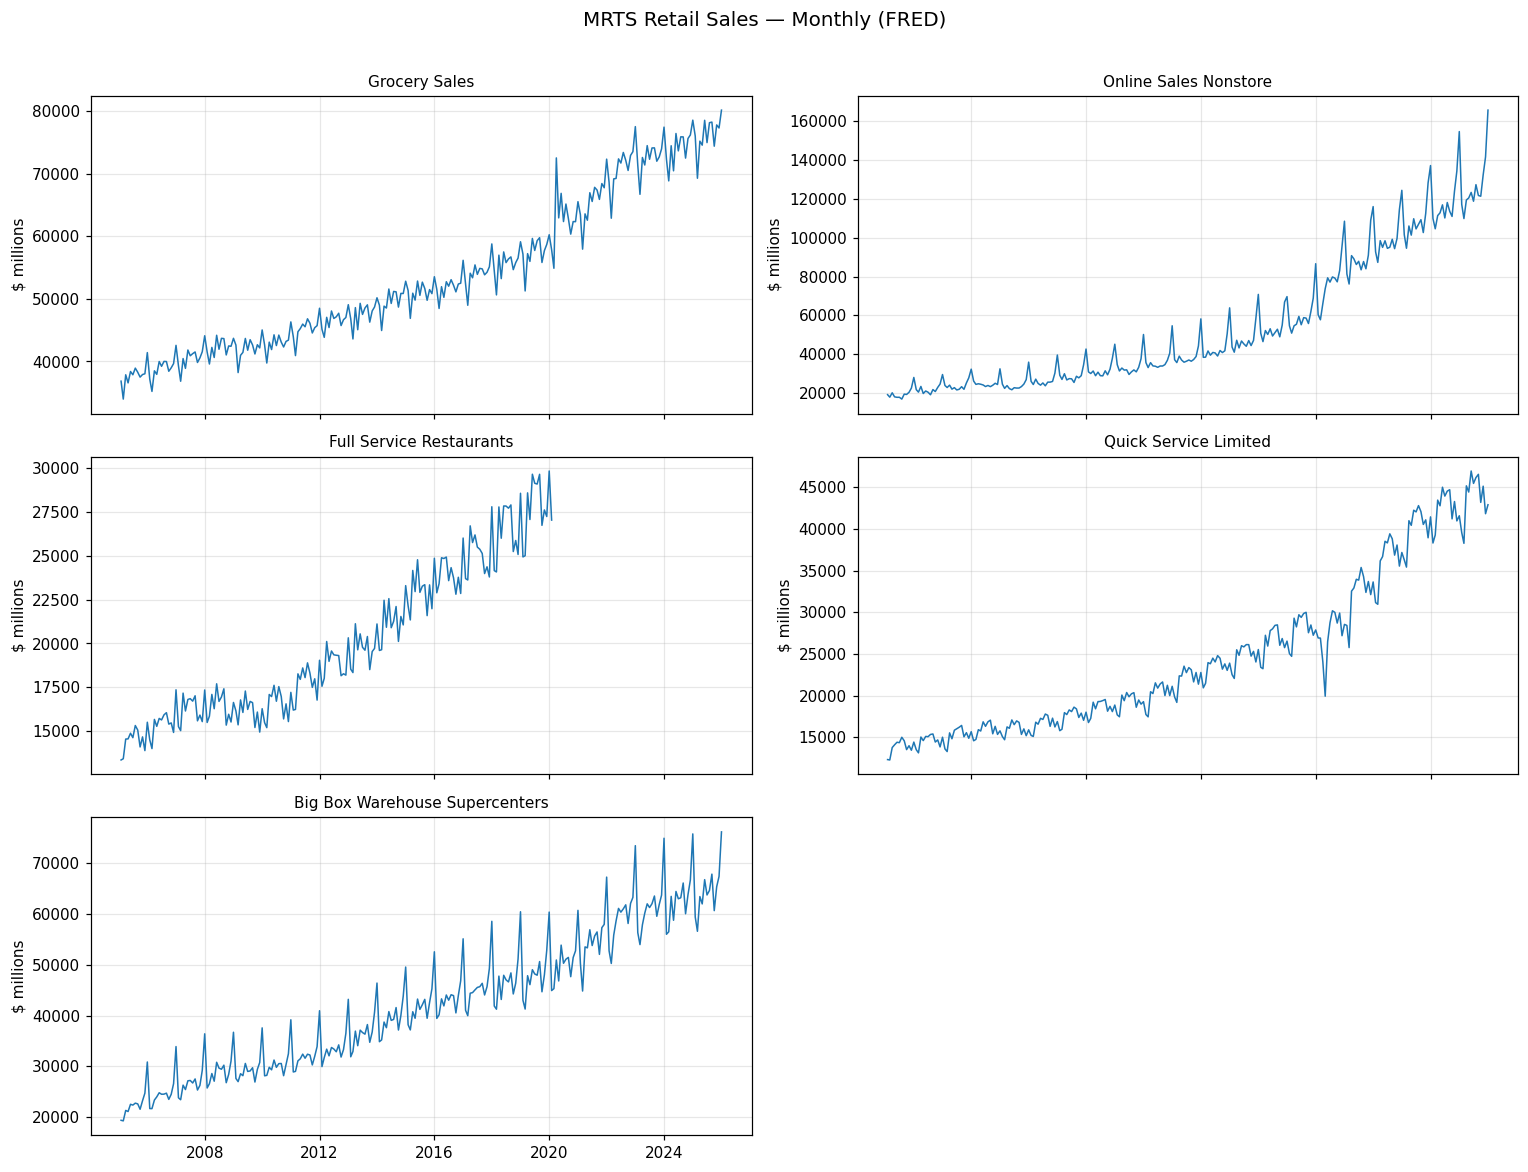

In [6]:
retail_cols = [col for col in retail_m.columns if not col.startswith("pump_price")]
n_cols = len(retail_cols)
n_rows = (n_cols + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3.5 * n_rows), sharex=True)
axes = axes.flatten()

for i, col in enumerate(retail_cols):
    ax = axes[i]
    s = retail_m[col].dropna()
    ax.plot(s.index, s.values, linewidth=1)
    ax.set_title(col.replace("mrts_", "").replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("$ millions")

# Hide unused subplot if odd number
for j in range(n_cols, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("MRTS Retail Sales — Monthly (FRED)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

In [7]:
# Load seasonally adjusted series for crisis comparison charts (§6).
# SA removes December spikes that obscure the counter/procyclical story.
crisis_sa = loader.load_crisis_sa(start="2005-01-01")
print(
    f"crisis_sa: {crisis_sa.shape}  |  "
    f"{crisis_sa.index.min().date()} → {crisis_sa.index.max().date()}"
)
crisis_sa.tail()

crisis_sa: (252, 4)  |  2005-01-31 → 2025-12-31


,grocery_sa,online_nonstore_sa,big_box_warehouse_sa,food_services_sa
2025-08-31,76831.0,129257.0,64664.0,99551.0
2025-09-30,76816.0,128369.0,64728.0,99797.0
2025-10-31,76836.0,129286.0,64781.0,99705.0
2025-11-30,76579.0,130174.0,64798.0,100241.0
2025-12-31,76752.0,130499.0,64916.0,100012.0


## 3. Seasonal Decomposition (STL)

**STL** (Seasonal and Trend decomposition using Loess) separates a time series into three components:
- **Trend:** long-run direction
- **Seasonal:** repeating annual pattern (period=12 for monthly data)
- **Residual:** what's left — noise plus structural breaks

STL is preferred over classical decomposition because its Loess smoother handles changing seasonal amplitudes and is robust to outliers. We apply it to grocery sales as the highest-volume retail channel.

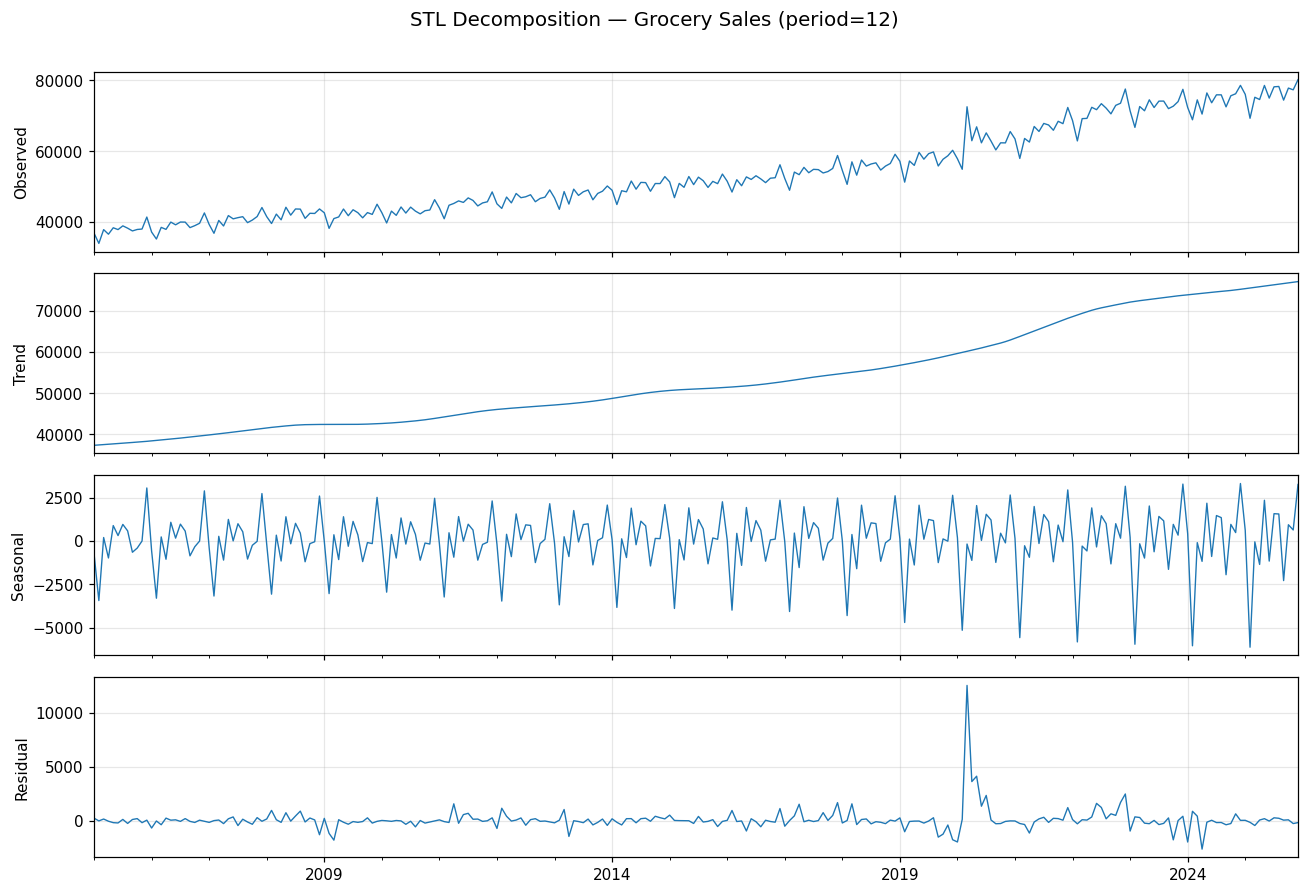

In [8]:
grocery = retail_m["mrts_grocery_sales"].dropna()

stl = STL(grocery, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
components = [
    ("Observed", grocery),
    ("Trend", result.trend),
    ("Seasonal", result.seasonal),
    ("Residual", result.resid),
]
for ax, (label, data) in zip(axes, components):
    data.plot(ax=ax, linewidth=0.9)
    ax.set_ylabel(label, fontsize=10)

fig.suptitle("STL Decomposition — Grocery Sales (period=12)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 4. Cross-Correlation: Macro → Retail

Does GDP growth **lead** retail sales growth? We compute cross-correlations at lags −24 to +24 months between year-over-year GDP growth and year-over-year grocery sales growth.

- **Negative lags** mean GDP leads retail (useful for forecasting)
- **Positive lags** mean retail leads GDP
- A peak at lag −3 would indicate GDP changes predict grocery sales 3 months ahead

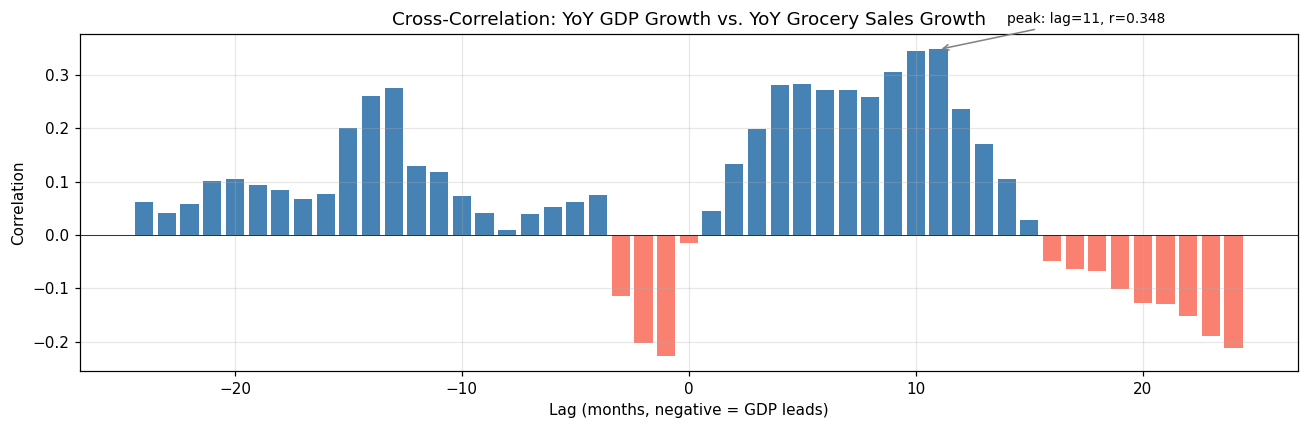

In [9]:
# Year-over-year growth rates from the monthly panel
gdp_growth = panel_m["real_gdp"].pct_change(12).dropna()
grocery_growth = panel_m["mrts_grocery_sales"].pct_change(12).dropna()

# Align on common index
common = gdp_growth.index.intersection(grocery_growth.index)
gdp_g = gdp_growth.loc[common].values
gro_g = grocery_growth.loc[common].values

max_lag = 24
lags = range(-max_lag, max_lag + 1)
xcorr = [
    np.corrcoef(
        gdp_g[max_lag : len(gdp_g) - max_lag], np.roll(gro_g, -lag)[max_lag : len(gro_g) - max_lag]
    )[0, 1]
    for lag in lags
]

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["steelblue" if x >= 0 else "salmon" for x in xcorr]
ax.bar(lags, xcorr, color=colors, width=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Lag (months, negative = GDP leads)")
ax.set_ylabel("Correlation")
ax.set_title("Cross-Correlation: YoY GDP Growth vs. YoY Grocery Sales Growth")

peak_lag = list(lags)[np.argmax(np.abs(xcorr))]
peak_val = xcorr[np.argmax(np.abs(xcorr))]
ax.annotate(
    f"peak: lag={peak_lag}, r={peak_val:.3f}",
    xy=(peak_lag, peak_val),
    fontsize=9,
    xytext=(peak_lag + 3, peak_val + 0.05 * np.sign(peak_val)),
    arrowprops=dict(arrowstyle="->", color="gray"),
)
fig.tight_layout()
plt.show()

## 5. Correlation Matrix

Pairwise Pearson correlations across all panel columns (levels, not growth rates). High correlations between predictors signal collinearity risk — the regression model in `Retail_Forecast.ipynb` quantifies this via VIF on the actual design matrix and uses HAC standard errors to produce reliable inference despite correlated regressors.

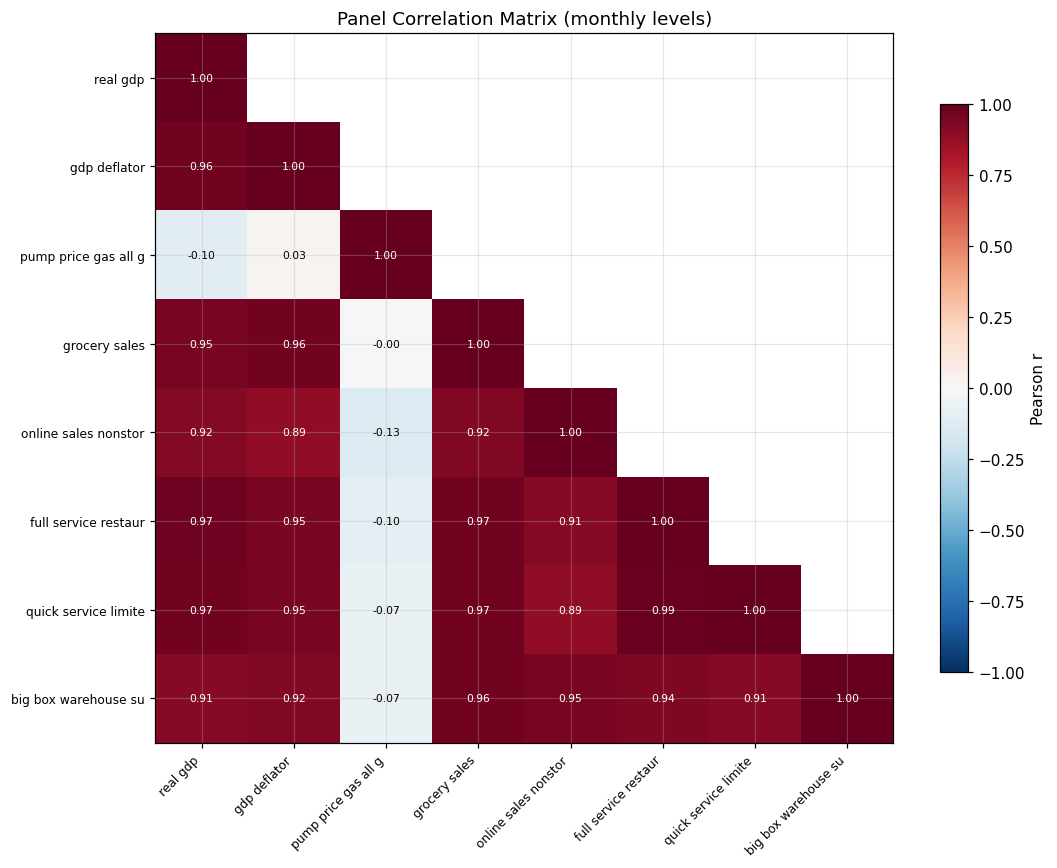

In [10]:
corr = panel_m.dropna().corr()

# Mask upper triangle for readability (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_masked = corr.where(~mask)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    np.ma.masked_invalid(corr_masked.values),
    cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto",
)

labels = [c.replace("mrts_", "").replace("_", " ")[:20] for c in corr.columns]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

# Annotate only lower triangle + diagonal
for i in range(len(corr)):
    for j in range(len(corr)):
        if not mask[i, j]:
            val = corr.iloc[i, j]
            color = "white" if abs(val) > 0.7 else "black"
            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center", fontsize=7, color=color,
            )

fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Panel Correlation Matrix (monthly levels)", fontsize=12)
fig.tight_layout()
plt.show()

## 7. Post-Crisis Countercyclicality

Do all retail channels respond to recessions the same way? **No.** Some channels are *countercyclical* — they gain share during downturns (grocery, as consumers eat at home) — while others are *procyclical* (restaurants decline as discretionary spending contracts).

We index each series to 100 at the crisis onset and compare trajectories through two recessions:
- **Great Recession** (Dec 2007 – Jun 2009): a prolonged credit-driven downturn
- **COVID-19** (Feb – Apr 2020): a sharp, exogenous shock with rapid policy response

> **Why SA here?** The STL section (§3) uses NSA data to decompose the seasonal signal. For crisis comparison, we switch to **Seasonally Adjusted (SA)** series so that December spikes don't dominate the indexed charts. Individual restaurant SA series don't exist in FRED, so we use the **aggregate Food Services & Drinking Places** (`MRTSSM722USS`) — the countercyclical/procyclical story still holds at this level.

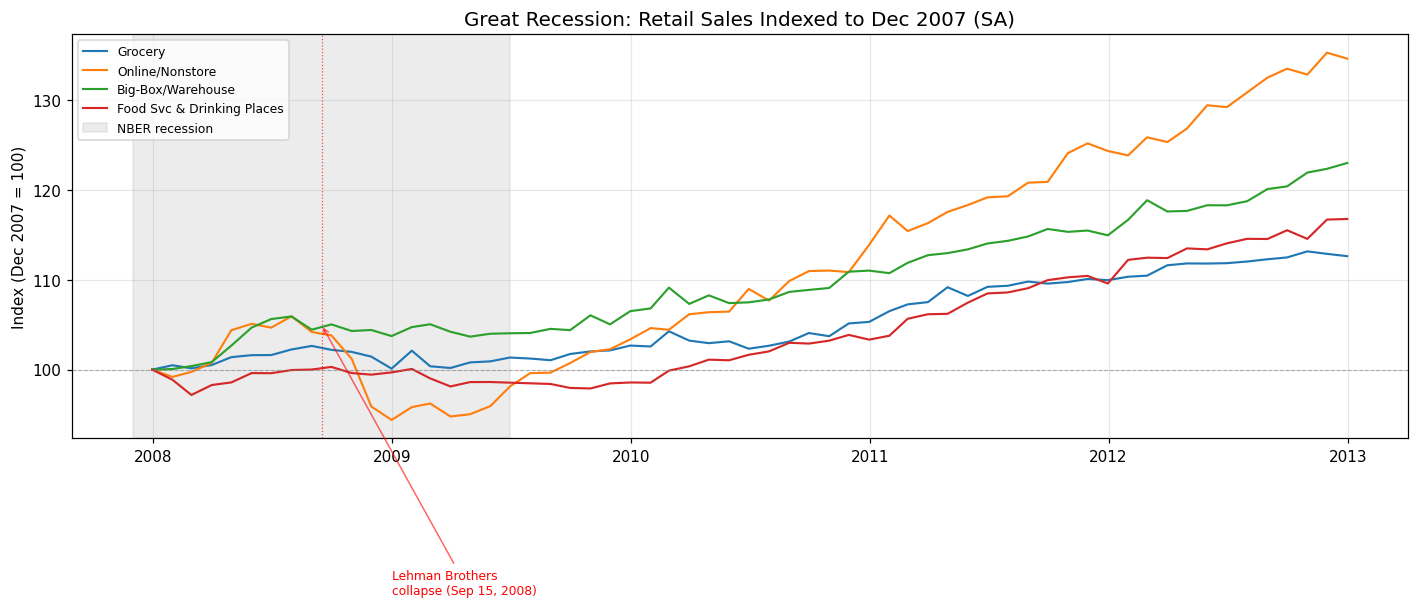

In [11]:
# --- Great Recession (SA series) ---
ref_date_gr = "2007-12-31"
plot_end_gr = "2012-12-31"
nber_gr = ("2007-12-01", "2009-06-30")  # Dec 2007 – Jun 2009
lehman_date = "2008-09-15"

crisis_cols = ["grocery_sa", "online_nonstore_sa", "big_box_warehouse_sa", "food_services_sa"]
labels = ["Grocery", "Online/Nonstore", "Big-Box/Warehouse", "Food Svc & Drinking Places"]

ref_vals_gr = crisis_sa[crisis_cols].loc[ref_date_gr]
assert ref_vals_gr.notna().all(), (
    f"Missing data at ref date {ref_date_gr}: {ref_vals_gr[ref_vals_gr.isna()].index.tolist()}"
)
indexed_gr = (crisis_sa[crisis_cols].loc[ref_date_gr:plot_end_gr] / ref_vals_gr) * 100

fig, ax = plt.subplots(figsize=(13, 6))
for col, label in zip(crisis_cols, labels):
    ax.plot(indexed_gr.index, indexed_gr[col], linewidth=1.4, label=label)

ax.axhline(100, color="gray", linewidth=0.7, linestyle="--", alpha=0.6)
ax.axvspan(
    pd.Timestamp(nber_gr[0]),
    pd.Timestamp(nber_gr[1]),
    color="gray",
    alpha=0.15,
    label="NBER recession",
)
ax.axvline(
    pd.Timestamp(lehman_date),
    color="red",
    linewidth=0.8,
    linestyle=":",
    alpha=0.7,
)
ax.annotate(
    "Lehman Brothers\ncollapse (Sep 15, 2008)",
    xy=(pd.Timestamp(lehman_date), 105),
    fontsize=8,
    color="red",
    ha="left",
    xytext=(pd.Timestamp("2009-01-01"), 75),
    arrowprops=dict(arrowstyle="->", color="red", alpha=0.6),
)

ax.set_ylabel("Index (Dec 2007 = 100)")
ax.set_title(
    "Great Recession: Retail Sales Indexed to Dec 2007 (SA)",
    fontsize=13,
)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

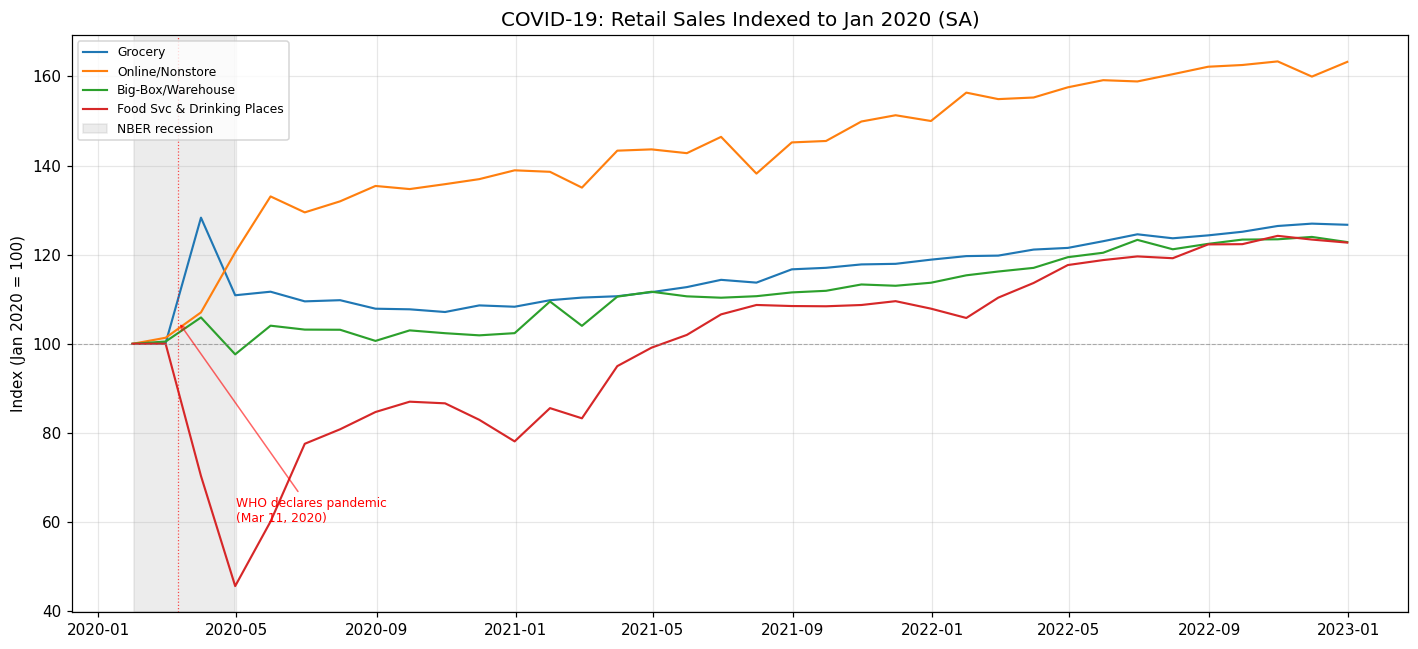

In [12]:
# --- COVID-19 Crisis (SA series) ---
ref_date_covid = "2020-01-31"
plot_end_covid = "2022-12-31"
nber_covid = ("2020-02-01", "2020-04-30")  # Feb–Apr 2020
who_date = "2020-03-11"  # WHO pandemic declaration

crisis_cols = ["grocery_sa", "online_nonstore_sa", "big_box_warehouse_sa", "food_services_sa"]
labels = ["Grocery", "Online/Nonstore", "Big-Box/Warehouse", "Food Svc & Drinking Places"]

ref_vals_covid = crisis_sa[crisis_cols].loc[ref_date_covid]
missing = ref_vals_covid[ref_vals_covid.isna()].index.tolist()
assert ref_vals_covid.notna().all(), f"Missing data at ref date {ref_date_covid}: {missing}"
indexed_covid = (crisis_sa[crisis_cols].loc[ref_date_covid:plot_end_covid] / ref_vals_covid) * 100

fig, ax = plt.subplots(figsize=(13, 6))
for col, label in zip(crisis_cols, labels):
    ax.plot(
        indexed_covid.index,
        indexed_covid[col],
        linewidth=1.4,
        label=label,
    )

ax.axhline(100, color="gray", linewidth=0.7, linestyle="--", alpha=0.6)
ax.axvspan(
    pd.Timestamp(nber_covid[0]),
    pd.Timestamp(nber_covid[1]),
    color="gray",
    alpha=0.15,
    label="NBER recession",
)
ax.axvline(
    pd.Timestamp(who_date),
    color="red",
    linewidth=0.8,
    linestyle=":",
    alpha=0.7,
)
ax.annotate(
    "WHO declares pandemic\n(Mar 11, 2020)",
    xy=(pd.Timestamp(who_date), 105),
    fontsize=8,
    color="red",
    ha="left",
    xytext=(pd.Timestamp("2020-05-01"), 60),
    arrowprops=dict(arrowstyle="->", color="red", alpha=0.6),
)

ax.set_ylabel("Index (Jan 2020 = 100)")
ax.set_title(
    "COVID-19: Retail Sales Indexed to Jan 2020 (SA)",
    fontsize=13,
)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

## 7. Summary

**Key findings:**

1. **Seasonality is strong** — STL confirms a pronounced annual cycle in grocery sales, with December peaks and January troughs. Any forecasting model must account for this.

2. **GDP leads retail** — Cross-correlation shows GDP growth changes anticipate retail sales changes by several months, validating the use of macro indices as predictors.

3. **High collinearity** — The correlation matrix shows many retail series are strongly correlated (they all respond to the same macro cycle). The regression model in `Retail_Forecast.ipynb` handles this via VIF diagnostics and HAC standard errors.

4. **COVID structural break** — The 2020 disruption appears as a large residual in STL and distorts correlation estimates. Modeling strategies include regime indicators or sample truncation.

5. **Counter/procyclical dynamics** — Grocery and online retail are countercyclical (stable or rising during recessions), while food services are procyclical (sharp declines). This asymmetry means a single-model approach may not capture channel-level behavior — consider channel-specific or interaction terms.

**Implications for the forecasting model** (see `Retail_Forecast.ipynb`):
- Use HAC standard errors (already in `RegressionDiagnostics`)
- Monitor VIF in diagnostics to guide predictor selection
- Consider seasonal differencing or explicit seasonal terms
- Cross-correlation lag structure informs which macro lags to include
- Channel-specific crisis response suggests regime-aware modeling